In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from collections import Counter
from collections import defaultdict

## Counts per category of participation level

In [2]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)

In [3]:
df_expanded = df.assign(Pattern=df['Pattern'].str.split(',')).explode('Pattern')

# Step 2: Convert Pattern column values to string type (to handle consistency)
df_expanded['Pattern'] = df_expanded['Pattern'].str.strip()

# Step 3: Group by 'Pattern' and sum 'Count'
result = df_expanded.groupby('Pattern')['Count'].sum()

# Step 4: Sort the result (optional)
result = result.sort_index()

print(result)

Pattern
0.0    14291
1.0     2008
2.0     3108
3.0     3394
Name: Count, dtype: int64


## Paragraph turns with a column for each level

In [4]:
paragraph_turns = pd.read_csv("../data/paragraph_turns_with_emotions.csv")
paragraph_turns['collectiveAction'] = 1 - paragraph_turns['collectiveAction']
paragraph_turns['collectiveActionMulti'] = paragraph_turns['collectiveActionMulti'].astype(str)

In [5]:
paragraph_turns['problem_solution'] = paragraph_turns['collectiveActionMulti'].apply(lambda x: 1 if '0.0' in x else 0)
paragraph_turns['call_to_action'] = paragraph_turns['collectiveActionMulti'].apply(lambda x: 1 if '1.0' in x else 0)
paragraph_turns['intention'] = paragraph_turns['collectiveActionMulti'].apply(lambda x: 1 if '2.0' in x else 0)
paragraph_turns['execution'] = paragraph_turns['collectiveActionMulti'].apply(lambda x: 1 if '3.0' in x else 0)

In [6]:
# paragraph_turns.to_csv("../data/paragraph_turns_full.csv", index=False)

In [7]:
problem_solution_counts = paragraph_turns['problem_solution'].value_counts()
print(problem_solution_counts)
call_to_action_counts = paragraph_turns['call_to_action'].value_counts()
print(call_to_action_counts)
intention_counts = paragraph_turns['intention'].value_counts()
print(intention_counts)
execution_counts = paragraph_turns['execution'].value_counts()
print(execution_counts)

problem_solution
0    334636
1     10096
Name: count, dtype: int64
call_to_action
0    343077
1      1655
Name: count, dtype: int64
intention
0    341972
1      2760
Name: count, dtype: int64
execution
0    341865
1      2867
Name: count, dtype: int64


### Matrix between emotions and the levels of collective action

In [8]:
paragraph_turns.columns

Index(['sentence', 'collectiveAction', 'racialJustice',
       'collectiveActionMulti', 'episode_id', 'sentence_length', 'speaker',
       'newSpeaker', 'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean',
       'mfcc4_sma3Mean', 'F0semitoneFrom27_5Hz_sma3nzMean',
       'F1frequency_sma3nzMean', 'startTime', 'endTime', 'duration',
       'turnCount', 'streak', 'streak_length', 'gratitude', 'excitement',
       'joy', 'neutral', 'approval', 'admiration', 'relief', 'caring',
       'optimism', 'realization', 'surprise', 'pride', 'desire', 'love',
       'annoyance', 'amusement', 'confusion', 'sadness', 'curiosity', 'fear',
       'disapproval', 'nervousness', 'disgust', 'disappointment', 'anger',
       'grief', 'remorse', 'embarrassment', 'problem_solution',
       'call_to_action', 'intention', 'execution'],
      dtype='object')

## Lift matrix

In [72]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)
df

,Pattern,Count
0,0.0,7037
1,2.0,1731
2,3.0,1674
3,"0.0, 0.0",955
4,1.0,837
...,...,...
522,"1.0, 2.0, 0.0, 0.0, 1.0, 0.0",1
523,"1.0, 3.0, 1.0, 1.0, 3.0, 0.0",1
524,"1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0",1
525,"1.0, 1.0, 2.0, 2.0, 3.0, 1.0, 1.0",1


In [ ]:
# Step 0: Define states and labels
labels = ["Problem-solution", "Call-to-action", "Intention", "Execution"]
states = ["0.0", "1.0", "2.0", "3.0"]

# Step 1: Extract transitions
def extract_transitions(pattern, count):
    states = pattern.split(", ")
    transitions = [(states[i], states[i+1]) for i in range(len(states)-1)]
    return [(A, B, count) for A, B in transitions]

all_transitions = []
for _, row in df.iterrows():
    all_transitions.extend(extract_transitions(row["Pattern"], row["Count"]))
len(all_transitions)
all_transitions

# Step 2: Aggregate transition counts
transition_counts = Counter()
from_counts = Counter()
to_counts = Counter()
total_transitions = 0

for A, B, count in all_transitions:
    transition_counts[(A, B)] += count
    from_counts[A] += count
    to_counts[B] += count
    total_transitions += count
transition_counts

# Step 3: Compute probabilities
P_B_given_A = {key: count / total_transitions for key, count in transition_counts.items()}
P_B = {B: count / total_transitions for B, count in to_counts.items()}

P_B_given_A
P_B

# Step 4: Compute lift
lift = {key: P_B_given_A[key] / P_B[key[1]] for key in transition_counts}
lift_df = pd.DataFrame([
    {"A": A, "B": B, "P_B_given_A": P_B_given_A[(A, B)], "P_B": P_B[B], "Lift": lift[(A, B)]}
    for A, B in lift
])
lift_df.sort_values(by="Lift", ascending=False)

lift_df

# Step 5: Create transition matrix for heatmap
states = ["0.0", "1.0", "2.0", "3.0"]
matrix = np.zeros((4, 4))
for (A, B), value in lift.items():
    i, j = states.index(A), states.index(B)
    matrix[i, j] = value

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="crest", fmt=".2f")
plt.ylabel("From")
plt.xlabel("To", labelpad=15)  # Move the x-axis label up
plt.gca().xaxis.set_label_position("top")  # Position x-axis label at the top
plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)  # Show labels at the top

# Add label to colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_label("Lift")

#plt.savefig("../plots/transition_matrix.pdf")

plt.show()

Counter({('0.0', '0.0'): 3715,
         ('0.0', '3.0'): 490,
         ('3.0', '0.0'): 448,
         ('2.0', '0.0'): 435,
         ('0.0', '1.0'): 422,
         ('0.0', '2.0'): 415,
         ('3.0', '3.0'): 385,
         ('1.0', '0.0'): 333,
         ('1.0', '1.0'): 234,
         ('2.0', '2.0'): 232,
         ('2.0', '3.0'): 165,
         ('3.0', '2.0'): 147,
         ('3.0', '1.0'): 140,
         ('1.0', '3.0'): 101,
         ('2.0', '1.0'): 92,
         ('1.0', '2.0'): 86})

In [11]:
# Calculate upper triangle sum (excluding diagonal)
upper_triangle_sum = np.sum(np.triu(matrix, k=1))

# Calculate lower triangle sum (excluding diagonal)
lower_triangle_sum = np.sum(np.tril(matrix, k=-1))

print("Upper Triangle Sum:", upper_triangle_sum)
print("Lower Triangle Sum:", lower_triangle_sum)

Upper Triangle Sum: 1.7071200941599713
Lower Triangle Sum: 0.6749098389054787


### v2 (aggregating identical consecutive symbols into one)

AEEEEEAAE to AEAE

In [12]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)
df

,Pattern,Count
0,0.0,7037
1,2.0,1731
2,3.0,1674
3,"0.0, 0.0",955
4,1.0,837
...,...,...
522,"1.0, 2.0, 0.0, 0.0, 1.0, 0.0",1
523,"1.0, 3.0, 1.0, 1.0, 3.0, 0.0",1
524,"1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0",1
525,"1.0, 1.0, 2.0, 2.0, 3.0, 1.0, 1.0",1


In [13]:
df = df.astype({"Pattern":"str"})
df["Pattern"] = df["Pattern"].apply(lambda x: x.split(", "))
df["Pattern"].head(10)

0              [0.0]
1              [2.0]
2              [3.0]
3         [0.0, 0.0]
4              [1.0]
5    [0.0, 0.0, 0.0]
6         [0.0, 3.0]
7         [2.0, 0.0]
8         [3.0, 0.0]
9         [3.0, 3.0]
Name: Pattern, dtype: object

In [14]:
def aggregate_consecutive(pattern):
    aggregated = [pattern[0]]
    for i in range(1, len(pattern)):
        if pattern[i] != pattern[i-1]:
            aggregated.append(pattern[i])
    return aggregated

df['Pattern'] = df['Pattern'].apply(aggregate_consecutive)
df.head(10)

,Pattern,Count
0,[0.0],7037
1,[2.0],1731
2,[3.0],1674
3,[0.0],955
4,[1.0],837
5,[0.0],271
6,"[0.0, 3.0]",145
7,"[2.0, 0.0]",140
8,"[3.0, 0.0]",138
9,[3.0],130


In [15]:
# # for all values in the list in the pattern column, convert them to int
# df["Pattern"] = df["Pattern"].apply(lambda x: [int(float(i)) for i in x])
# df.head(10)

In [ ]:
# Step 0: Define states and labels
labels = ["Problem-solution", "Call-to-action", "Intention", "Execution"]
states = ["0.0", "1.0", "2.0", "3.0"]

# Step 1: Extract transitions
# def extract_transitions(pattern, count):
#     states = pattern.split(", ")
#     transitions = [(states[i], states[i+1]) for i in range(len(states)-1)]
#     return [(A, B, count) for A, B in transitions]

# all_transitions = []
# for _, row in df.iterrows():
#     all_transitions.extend(extract_transitions(row["Pattern"], row["Count"]))
# len(all_transitions)
# all_transitions

def extract_transitions(pattern, count):
    # Ensure pattern is a list before processing
    if not isinstance(pattern, list):
        pattern = eval(pattern)  # Convert string representation of a list into an actual list (if needed)
    
    transitions = [(str(pattern[i]), str(pattern[i+1])) for i in range(len(pattern)-1)]
    return [(A, B, count) for A, B in transitions]

all_transitions = []
for _, row in df.iterrows():
    all_transitions.extend(extract_transitions(row["Pattern"], row["Count"]))
all_transitions

# Step 2: Aggregate transition counts
transition_counts = Counter()
from_counts = Counter()
to_counts = Counter()
total_transitions = 0

for A, B, count in all_transitions:
    transition_counts[(A, B)] += count
    from_counts[A] += count
    to_counts[B] += count
    total_transitions += count
transition_counts

# Step 3: Compute probabilities
P_B_given_A = {key: count / total_transitions for key, count in transition_counts.items()}
P_B = {B: count / total_transitions for B, count in to_counts.items()}

P_B_given_A
P_B

# Step 4: Compute lift
lift = {key: P_B_given_A[key] / P_B[key[1]] for key in transition_counts}
lift_df = pd.DataFrame([
    {"A": A, "B": B, "P_B_given_A": P_B_given_A[(A, B)], "P_B": P_B[B], "Lift": lift[(A, B)]}
    for A, B in lift
])
lift_df.sort_values(by="Lift", ascending=False)

lift_df

# Step 5: Create transition matrix for heatmap
states = ["0.0", "1.0", "2.0", "3.0"]
matrix = np.zeros((4, 4))
for (A, B), value in lift.items():
    i, j = states.index(A), states.index(B)
    matrix[i, j] = value

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="crest", fmt=".2f")
plt.ylabel("From")
plt.xlabel("To", labelpad=15)  # Move the x-axis label up
plt.gca().xaxis.set_label_position("top")  # Position x-axis label at the top
plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)  # Show labels at the top

# Add label to colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_label("Lift")

#plt.savefig("../plots/transition_matrix_no_diagonal.pdf")

plt.show()

TypeError: object of type 'float' has no len()

In [17]:
# Calculate upper triangle sum (excluding diagonal)
upper_triangle_sum = np.sum(np.triu(matrix, k=1))

# Calculate lower triangle sum (excluding diagonal)
lower_triangle_sum = np.sum(np.tril(matrix, k=-1))

print("Upper Triangle Sum:", upper_triangle_sum)
print("Lower Triangle Sum:", lower_triangle_sum)

Upper Triangle Sum: 2.418408086986069
Lower Triangle Sum: 1.5815919130139315


## v3 (non-consecutive)

- #1 A followed by B at any point in the same paragraph (so AAB has 2 AB transitions?)
- #2 A -> B -> A,B
- #3 

In [18]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)

In [19]:
# Dictionary to store transition counts
transition_counts = defaultdict(int)

# Process each row
for pattern, row_count in zip(df["Pattern"], df["Count"]):
    numbers = list(map(float, pattern.split(", ")))  # Convert to list of floats
    
    # Count transitions within this row
    local_transitions = defaultdict(int)  # Track transitions in this row
    
    for i in range(len(numbers)):
        A = numbers[i]
        for j in range(i + 1, len(numbers)):  # Look at elements appearing later
            B = numbers[j]
            if A != B:  # Ensure A → A is not counted
                local_transitions[(A, B)] += 1  # Count occurrences in this row
    
    # Multiply by the row's count and add to the global transition counts
    for transition, count in local_transitions.items():
        transition_counts[transition] += count * row_count

# Convert results to DataFrame
transition_df = pd.DataFrame(
    [(A, B, count) for (A, B), count in transition_counts.items()],
    columns=["From", "To", "Count"]
)

# Sort by frequency
transition_df = transition_df.sort_values(by="Count", ascending=False)

transition_counts

defaultdict(int,
            {(0.0, 3.0): 1356,
             (2.0, 0.0): 1348,
             (3.0, 0.0): 1211,
             (0.0, 2.0): 1477,
             (0.0, 1.0): 1612,
             (1.0, 0.0): 1127,
             (2.0, 3.0): 374,
             (3.0, 2.0): 361,
             (3.0, 1.0): 419,
             (1.0, 3.0): 312,
             (2.0, 1.0): 317,
             (1.0, 2.0): 281})

In [ ]:
# transition_matrix = transition_df.pivot(index='From', columns='To', values='Count').fillna(0)
# plt.figure(figsize=(8, 6))
# sns.heatmap(transition_matrix, annot=True, fmt=".0f", cmap="Blues", cbar_kws={'label': 'Count'})
# plt.title("Transition Matrix")
# plt.xlabel("To")
# plt.ylabel("From")
# plt.show()

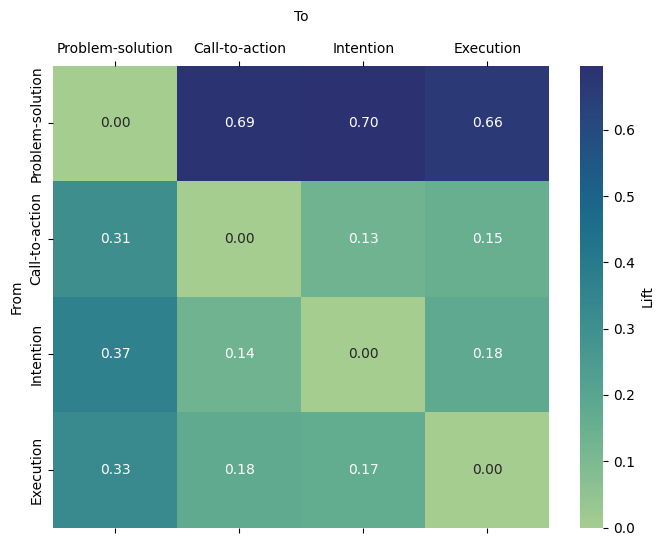

In [20]:
# Step 3: Compute probabilities
total_transitions = sum(transition_counts.values())
to_counts = defaultdict(int)
for (A, B), count in transition_counts.items():
    to_counts[B] += count  # Accumulate total counts for each "B"

P_B_given_A = {key: count / total_transitions for key, count in transition_counts.items()}
P_B = {B: count / total_transitions for B, count in to_counts.items()}

# Step 4: Compute lift
lift = {key: P_B_given_A[key] / P_B[key[1]] for key in transition_counts}
lift_df = pd.DataFrame([
    {"A": A, "B": B, "P_B_given_A": P_B_given_A[(A, B)], "P_B": P_B[B], "Lift": lift[(A, B)]}
    for A, B in lift
])
lift_df.sort_values(by="Lift", ascending=False)

lift_df

# Step 5: Create transition matrix for heatmap
#states = ["0.0", "1.0", "2.0", "3.0"]
states = [0.0, 1.0, 2.0, 3.0]  # Floats instead of strings
labels = ["Problem-solution", "Call-to-action", "Intention", "Execution"]
matrix = np.zeros((4, 4))
for (A, B), value in lift.items():
    i, j = states.index(A), states.index(B)
    matrix[i, j] = value

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="crest", fmt=".2f")
plt.ylabel("From")
plt.xlabel("To", labelpad=15)  # Move the x-axis label up
plt.gca().xaxis.set_label_position("top")  # Position x-axis label at the top
plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)  # Show labels at the top

# Add label to colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_label("Lift")

#plt.savefig("../plots/transition_matrix_no_diagonal.pdf")

plt.show()

In [21]:
# Calculate upper triangle sum (excluding diagonal)
upper_triangle_sum = np.sum(np.triu(matrix, k=1))

# Calculate lower triangle sum (excluding diagonal)
lower_triangle_sum = np.sum(np.tril(matrix, k=-1))

print("Upper Triangle Sum:", upper_triangle_sum)
print("Lower Triangle Sum:", lower_triangle_sum)

Upper Triangle Sum: 2.516178358696727
Lower Triangle Sum: 1.483821641303273


## v4 (from one paragraph to the other)

In [106]:
paragraph_turns = pd.read_csv("../data/paragraph_turns_full.csv")

In [ ]:
# import pandas as pd
# from collections import Counter

# # Define column indices
# categories = ['problem_solution', 'call_to_action', 'intention', 'execution']
# indices = {col: str(i) + '.0' for i, col in enumerate(categories)}

# # Initialize Counter
# transition_counts = Counter()

# # Iterate through rows to count transitions
# for i in range(len(paragraph_turns) - 1):
#     for col1, idx1 in indices.items():
#         for col2, idx2 in indices.items():
#             if paragraph_turns.iloc[i][col1] == 1 and paragraph_turns.iloc[i + 1][col2] == 1:
#                 transition_counts[(idx1, idx2)] += 1

# # Print results
# print(transition_counts)

Counter({('0.0', '0.0'): 814, ('2.0', '0.0'): 186, ('0.0', '2.0'): 163, ('3.0', '0.0'): 160, ('0.0', '3.0'): 141, ('0.0', '1.0'): 124, ('1.0', '0.0'): 89, ('3.0', '3.0'): 83, ('2.0', '2.0'): 76, ('2.0', '3.0'): 70, ('1.0', '1.0'): 66, ('3.0', '2.0'): 64, ('2.0', '1.0'): 43, ('3.0', '1.0'): 35, ('1.0', '3.0'): 30, ('1.0', '2.0'): 24})


In [107]:
# Define column indices
categories = ['problem_solution', 'call_to_action', 'intention', 'execution']
indices = {col: str(i) + '.0' for i, col in enumerate(categories)}

# Initialize Counter
transition_counts = Counter()

# Iterate through rows to count transitions
for i in range(len(paragraph_turns) - 1):
    for col1, idx1 in indices.items():
        for col2, idx2 in indices.items():
            if paragraph_turns.iloc[i][col1] == 1 and paragraph_turns.iloc[i + 1][col2] == 1 and idx1 != idx2:
                transition_counts[(idx1, idx2)] += 1

# Print results
print(transition_counts)

Counter({('2.0', '0.0'): 186, ('0.0', '2.0'): 163, ('3.0', '0.0'): 160, ('0.0', '3.0'): 141, ('0.0', '1.0'): 124, ('1.0', '0.0'): 89, ('2.0', '3.0'): 70, ('3.0', '2.0'): 64, ('2.0', '1.0'): 43, ('3.0', '1.0'): 35, ('1.0', '3.0'): 30, ('1.0', '2.0'): 24})


In [ ]:
# df = paragraph_turns

# # Explicit mapping of column names to their correct indices
# category_map = {
#     'problem_solution': '0.0',
#     'call_to_action': '1.0',
#     'intention': '2.0',
#     'execution': '3.0'
# }

# # Get column indices in the dataframe
# category_indices = {df.columns.get_loc(col): label for col, label in category_map.items()}

# # Convert DataFrame to NumPy for efficiency
# data = df.to_numpy()
# num_rows, num_cols = data.shape

# # Precompute row indices where each category is 1
# ones_positions = {col_idx: np.where(data[:, col_idx] == 1)[0] for col_idx in category_indices.keys()}

# # Initialize Counter
# transition_counts = Counter()

# # Efficiently count transitions
# for col1_idx, idx1 in category_indices.items():
#     for col2_idx, idx2 in category_indices.items():
#         if idx1 == idx2:
#             continue  # Skip self-transitions (0.0 → 0.0, 1.0 → 1.0, etc.)

#         # Get positions where col1 == 1
#         rows_col1 = ones_positions[col1_idx]

#         # Get positions where col2 == 1
#         rows_col2 = ones_positions[col2_idx]

#         # Count valid transitions where row_col1 < row_col2
#         count = np.sum(np.searchsorted(rows_col2, rows_col1, side="right") < len(rows_col2))

#         if count > 0:
#             transition_counts[(idx1, idx2)] = count

# # Print results
# print(transition_counts)

Counter({('0.0', '1.0'): 10096, ('0.0', '3.0'): 10096, ('0.0', '2.0'): 10093, ('3.0', '1.0'): 2866, ('3.0', '0.0'): 2865, ('3.0', '2.0'): 2861, ('2.0', '0.0'): 2760, ('2.0', '1.0'): 2760, ('2.0', '3.0'): 2760, ('1.0', '3.0'): 1655, ('1.0', '0.0'): 1654, ('1.0', '2.0'): 1654})


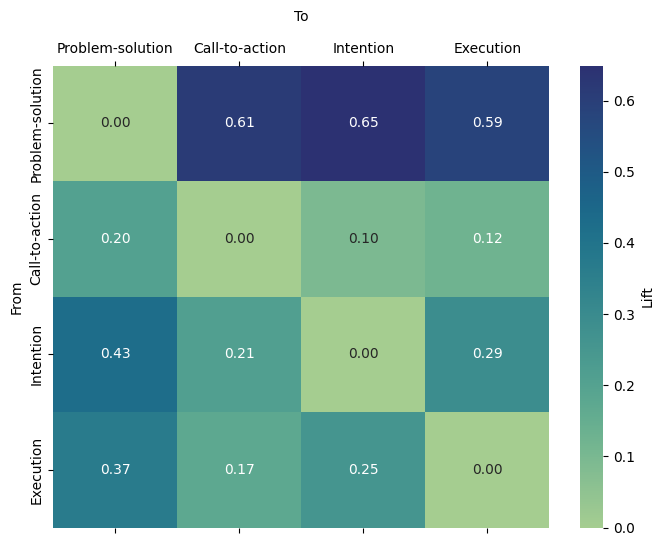

In [108]:
# Step 3: Compute probabilities
total_transitions = sum(transition_counts.values())
to_counts = defaultdict(int)
for (A, B), count in transition_counts.items():
    to_counts[B] += count  # Accumulate total counts for each "B"

P_B_given_A = {key: count / total_transitions for key, count in transition_counts.items()}
P_B = {B: count / total_transitions for B, count in to_counts.items()}

# Step 4: Compute lift
lift = {key: P_B_given_A[key] / P_B[key[1]] for key in transition_counts}
lift_df = pd.DataFrame([
    {"A": A, "B": B, "P_B_given_A": P_B_given_A[(A, B)], "P_B": P_B[B], "Lift": lift[(A, B)]}
    for A, B in lift
])
lift_df.sort_values(by="Lift", ascending=False)

lift_df

# Step 5: Create transition matrix for heatmap
states = ["0.0", "1.0", "2.0", "3.0"]
#states = [0.0, 1.0, 2.0, 3.0]  # Floats instead of strings
labels = ["Problem-solution", "Call-to-action", "Intention", "Execution"]
matrix = np.zeros((4, 4))
for (A, B), value in lift.items():
    i, j = states.index(A), states.index(B)
    matrix[i, j] = value

plt.figure(figsize=(8, 6))
ax = sns.heatmap(matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="crest", fmt=".2f")
plt.ylabel("From")
plt.xlabel("To", labelpad=15)  # Move the x-axis label up
plt.gca().xaxis.set_label_position("top")  # Position x-axis label at the top
plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)  # Show labels at the top

# Add label to colorbar
colorbar = ax.collections[0].colorbar
colorbar.set_label("Lift")

#plt.savefig("../plots/transition_matrix_no_diagonal.pdf")

plt.show()

## Prosodic features

- F0 vocal pitch can be modulated by speakers to emphasize words or signal question
- F1 often linked to vowel pronunciation, a key predictor of dialect, gender, and age
- MFCCs are designed to represent the short-term power spectrum of sounds, which are particularly useful for tasks such as emotion recognition

In [121]:
df = pd.read_csv("../data/paragraph_turns_full.csv")

In [113]:
prosodic = [
    'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean', 'mfcc4_sma3Mean',
    'F0semitoneFrom27_5Hz_sma3nzMean', 'F1frequency_sma3nzMean'
]
df[prosodic].describe()

,mfcc1_sma3Mean,mfcc2_sma3Mean,mfcc3_sma3Mean,mfcc4_sma3Mean,F0semitoneFrom27_5Hz_sma3nzMean,F1frequency_sma3nzMean
count,180113.000000,180113.000000,180113.000000,180113.000000,180113.000000,180113.000000
mean,21.878021,0.848978,11.866845,-5.157916,18.281555,687.634826
std,8.255787,9.785033,9.710608,10.334026,7.168344,89.919041
min,-47.048242,-80.751508,-67.954990,-70.742233,0.000000,0.000000
25%,17.530358,-4.703466,5.943774,-11.747914,14.178508,632.090976
50%,22.253898,1.535273,12.049848,-4.661469,18.676258,678.614014
75%,26.731619,7.160871,17.997736,1.864262,22.934985,734.575338
max,56.019362,62.455280,80.220354,56.832548,61.557517,1355.007010


In [110]:
columns_to_average = [
    'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean', 'mfcc4_sma3Mean',
    'F0semitoneFrom27_5Hz_sma3nzMean', 'F1frequency_sma3nzMean'
]

means_collective_action_0 = df[df['collectiveAction'] == 0][columns_to_average].mean()
means_collective_action_1 = df[df['collectiveAction'] == 1][columns_to_average].mean()

print("Average values for collectiveAction = 0:")
print(means_collective_action_0)
print("\nAverage values for collectiveAction = 1:")
print(means_collective_action_1)

Average values for collectiveAction = 0:
mfcc1_sma3Mean                     21.837193
mfcc2_sma3Mean                      0.761572
mfcc3_sma3Mean                     11.869663
mfcc4_sma3Mean                     -5.149977
F0semitoneFrom27_5Hz_sma3nzMean    18.235716
F1frequency_sma3nzMean            687.532102
dtype: float64

Average values for collectiveAction = 1:
mfcc1_sma3Mean                     22.414625
mfcc2_sma3Mean                      1.997768
mfcc3_sma3Mean                     11.829806
mfcc4_sma3Mean                     -5.262265
F0semitoneFrom27_5Hz_sma3nzMean    18.884036
F1frequency_sma3nzMean            688.984942
dtype: float64


In [111]:
# Step 1: Filter for collectiveAction = 1
df_ca1 = df[df['collectiveAction'] == 1]

# Step 2: Define relevant columns
columns_to_average = [
    'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean', 'mfcc4_sma3Mean',
    'F0semitoneFrom27_5Hz_sma3nzMean', 'F1frequency_sma3nzMean'
]

# Step 3: Compute means for each category
categories = ['problem_solution', 'call_to_action', 'intention', 'execution']
means_by_category = {}

for category in categories:
    means_by_category[category] = df_ca1[df_ca1[category] == 1][columns_to_average].mean()

# Step 4: Print results
for category, means in means_by_category.items():
    print(f"\nAverage values for {category} (collectiveAction = 1):")
    print(means)


Average values for problem_solution (collectiveAction = 1):
mfcc1_sma3Mean                     22.444857
mfcc2_sma3Mean                      2.000495
mfcc3_sma3Mean                     11.824059
mfcc4_sma3Mean                     -5.249212
F0semitoneFrom27_5Hz_sma3nzMean    18.885012
F1frequency_sma3nzMean            691.548484
dtype: float64

Average values for call_to_action (collectiveAction = 1):
mfcc1_sma3Mean                     21.713195
mfcc2_sma3Mean                      2.376819
mfcc3_sma3Mean                     11.492978
mfcc4_sma3Mean                     -4.705686
F0semitoneFrom27_5Hz_sma3nzMean    18.433420
F1frequency_sma3nzMean            687.834931
dtype: float64

Average values for intention (collectiveAction = 1):
mfcc1_sma3Mean                     22.317853
mfcc2_sma3Mean                      2.092420
mfcc3_sma3Mean                     11.686022
mfcc4_sma3Mean                     -5.330639
F0semitoneFrom27_5Hz_sma3nzMean    18.936046
F1frequency_sma3nzMean         

In [127]:
df = df.dropna(subset=prosodic)

In [129]:
from scipy.stats import ttest_ind, mannwhitneyu

prosodic = [
    'mfcc1_sma3Mean', 'mfcc2_sma3Mean', 'mfcc3_sma3Mean', 'mfcc4_sma3Mean',
    'F0semitoneFrom27_5Hz_sma3nzMean', 'F1frequency_sma3nzMean'
]

for feature in prosodic:
    group0 = df[df['collectiveAction'] == 0][feature]
    group1 = df[df['collectiveAction'] == 1][feature]
    
    t_stat, p_ttest = ttest_ind(group0, group1, equal_var=False)  # Welch's t-test
    u_stat, p_mannwhitney = mannwhitneyu(group0, group1, alternative='two-sided')
    
    print(f"{feature}: t-test p-value = {p_ttest:.4f}, Mann-Whitney p-value = {p_mannwhitney:.4f}")


mfcc1_sma3Mean: t-test p-value = 0.0000, Mann-Whitney p-value = 0.0000
mfcc2_sma3Mean: t-test p-value = 0.0000, Mann-Whitney p-value = 0.0000
mfcc3_sma3Mean: t-test p-value = 0.6287, Mann-Whitney p-value = 0.8334
mfcc4_sma3Mean: t-test p-value = 0.2042, Mann-Whitney p-value = 0.1142
F0semitoneFrom27_5Hz_sma3nzMean: t-test p-value = 0.0000, Mann-Whitney p-value = 0.0000
F1frequency_sma3nzMean: t-test p-value = 0.0399, Mann-Whitney p-value = 0.0086


In [130]:
import numpy as np

def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.var(x) + np.var(y)) / 2)

for feature in prosodic:
    d = cohens_d(df[df['collectiveAction'] == 0][feature], df[df['collectiveAction'] == 1][feature])
    print(f"{feature}: Cohen's d = {d:.4f}")


mfcc1_sma3Mean: Cohen's d = -0.0739
mfcc2_sma3Mean: Cohen's d = -0.1294
mfcc3_sma3Mean: Cohen's d = 0.0043
mfcc4_sma3Mean: Cohen's d = 0.0112
F0semitoneFrom27_5Hz_sma3nzMean: Cohen's d = -0.0997
F1frequency_sma3nzMean: Cohen's d = -0.0174


In [131]:
from scipy.stats import pointbiserialr

for feature in prosodic:
    r, p_value = pointbiserialr(df['collectiveAction'], df[feature])
    print(f"{feature}: r = {r:.4f}, p-value = {p_value:.4f}")


mfcc1_sma3Mean: r = 0.0179, p-value = 0.0000
mfcc2_sma3Mean: r = 0.0324, p-value = 0.0000
mfcc3_sma3Mean: r = -0.0011, p-value = 0.6552
mfcc4_sma3Mean: r = -0.0028, p-value = 0.2372
F0semitoneFrom27_5Hz_sma3nzMean: r = 0.0232, p-value = 0.0000
F1frequency_sma3nzMean: r = 0.0041, p-value = 0.0788


In [134]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Handle missing data (drop rows with NaNs in prosodic features)
df_clean = df.dropna(subset=prosodic)

# Define X (prosodic features) and y (collectiveAction)
X = df_clean[prosodic]
y = df_clean['collectiveAction']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add an intercept to the model (constant term)
X_scaled = sm.add_constant(X_scaled)

# Fit the logistic regression model
model = sm.Logit(y, X_scaled)
result = model.fit()

# Output the summary which includes p-values
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.254078
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       collectiveAction   No. Observations:               180113
Model:                          Logit   Df Residuals:                   180106
Method:                           MLE   Df Model:                            6
Date:                Tue, 01 Apr 2025   Pseudo R-squ.:                0.005410
Time:                        10:16:58   Log-Likelihood:                -45763.
converged:                       True   LL-Null:                       -46012.
Covariance Type:            nonrobust   LLR p-value:                2.393e-104
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5941      0.009   -277.526      0.000      -2.612      -2.576
x1             0.0861      0.

In [135]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Handle missing data (drop rows with NaNs in prosodic features)
df_clean = df.dropna(subset=prosodic)

# Define X (prosodic features) and y (collectiveAction)
X = df_clean[prosodic]
y = df_clean['problem_solution']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add an intercept to the model (constant term)
X_scaled = sm.add_constant(X_scaled)

# Fit the logistic regression model
model = sm.Logit(y, X_scaled)
result = model.fit()

# Output the summary which includes p-values
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.191240
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       problem_solution   No. Observations:               180113
Model:                          Logit   Df Residuals:                   180106
Method:                           MLE   Df Model:                            6
Date:                Tue, 01 Apr 2025   Pseudo R-squ.:                0.005569
Time:                        10:19:42   Log-Likelihood:                -34445.
converged:                       True   LL-Null:                       -34638.
Covariance Type:            nonrobust   LLR p-value:                 3.122e-80
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0106      0.011   -267.550      0.000      -3.033      -2.989
x1             0.0993      0.

In [136]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Handle missing data (drop rows with NaNs in prosodic features)
df_clean = df.dropna(subset=prosodic)

# Define X (prosodic features) and y (collectiveAction)
X = df_clean[prosodic]
y = df_clean['call_to_action']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add an intercept to the model (constant term)
X_scaled = sm.add_constant(X_scaled)

# Fit the logistic regression model
model = sm.Logit(y, X_scaled)
result = model.fit()

# Output the summary which includes p-values
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.047471
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:         call_to_action   No. Observations:               180113
Model:                          Logit   Df Residuals:                   180106
Method:                           MLE   Df Model:                            6
Date:                Tue, 01 Apr 2025   Pseudo R-squ.:                0.002934
Time:                        10:20:03   Log-Likelihood:                -8550.2
converged:                       True   LL-Null:                       -8575.4
Covariance Type:            nonrobust   LLR p-value:                 4.043e-09
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.8110      0.027   -181.213      0.000      -4.863      -4.759
x1            -0.0121      0.

In [137]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Handle missing data (drop rows with NaNs in prosodic features)
df_clean = df.dropna(subset=prosodic)

# Define X (prosodic features) and y (collectiveAction)
X = df_clean[prosodic]
y = df_clean['intention']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add an intercept to the model (constant term)
X_scaled = sm.add_constant(X_scaled)

# Fit the logistic regression model
model = sm.Logit(y, X_scaled)
result = model.fit()

# Output the summary which includes p-values
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.070838
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              intention   No. Observations:               180113
Model:                          Logit   Df Residuals:                   180106
Method:                           MLE   Df Model:                            6
Date:                Tue, 01 Apr 2025   Pseudo R-squ.:                0.003474
Time:                        10:20:13   Log-Likelihood:                -12759.
converged:                       True   LL-Null:                       -12803.
Covariance Type:            nonrobust   LLR p-value:                 4.992e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.3176      0.021   -206.922      0.000      -4.358      -4.277
x1             0.0534      0.

In [138]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Handle missing data (drop rows with NaNs in prosodic features)
df_clean = df.dropna(subset=prosodic)

# Define X (prosodic features) and y (collectiveAction)
X = df_clean[prosodic]
y = df_clean['execution']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add an intercept to the model (constant term)
X_scaled = sm.add_constant(X_scaled)

# Fit the logistic regression model
model = sm.Logit(y, X_scaled)
result = model.fit()

# Output the summary which includes p-values
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.075833
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              execution   No. Observations:               180113
Model:                          Logit   Df Residuals:                   180106
Method:                           MLE   Df Model:                            6
Date:                Tue, 01 Apr 2025   Pseudo R-squ.:                0.005270
Time:                        10:20:30   Log-Likelihood:                -13659.
converged:                       True   LL-Null:                       -13731.
Covariance Type:            nonrobust   LLR p-value:                 1.005e-28
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2391      0.020   -210.123      0.000      -4.279      -4.200
x1             0.0588      0.

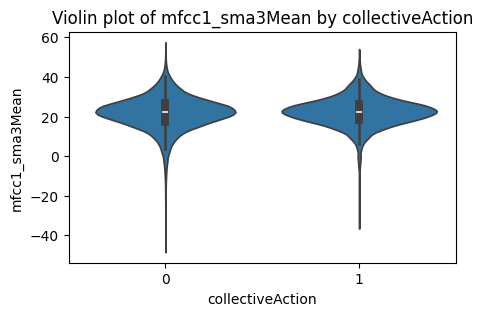

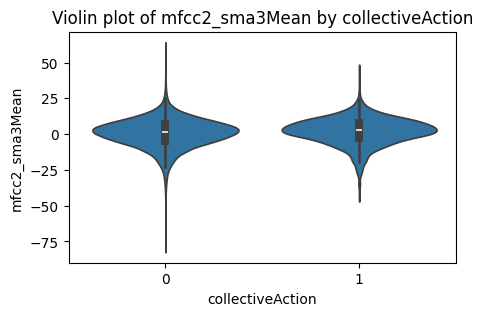

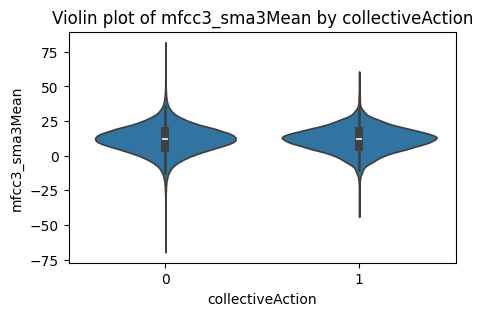

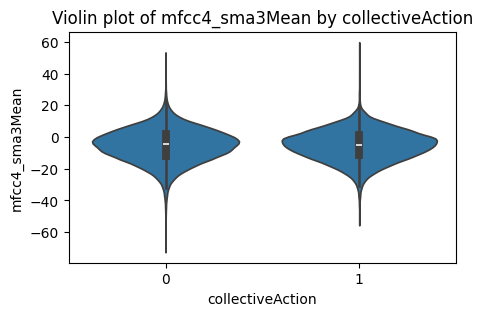

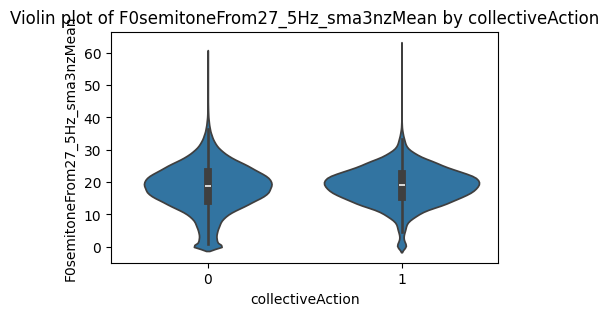

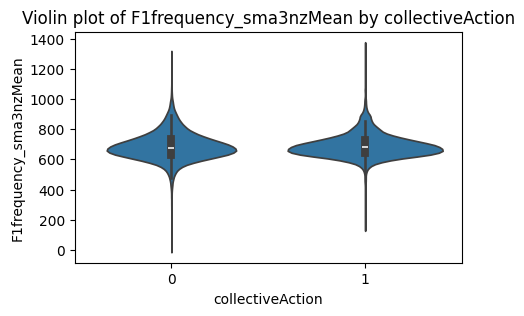

In [128]:
for feature in prosodic:
    plt.figure(figsize=(5, 3))
    sns.violinplot(x='collectiveAction', y=feature, data=df)
    plt.title(f"Violin plot of {feature} by collectiveAction")
    plt.show()


## Bursty

In [139]:
from bursty_dynamics.scores import calculate_scores
from bursty_dynamics.trains import train_detection, train_info, train_scores
from bursty_dynamics.visual import *

In [179]:
df = pd.read_csv("../data/paragraph_turns_full.csv")
len(df)

344732

In [157]:
df_rj = df[df['racialJustice'] == 1]
len(df_rj)

29082

In [158]:
df_rj = df_rj.dropna(subset=['startTime'])
len(df_rj)

23425

In [159]:
train_df = train_detection(df_rj, subject_id = 'episode_id', time_col = 'startTime', max_iet=30, time_unit='seconds')

In [160]:
# Step 1: Get unique (episode_id, train_id) pairs
unique_combinations = train_df[['episode_id', 'train_id']].drop_duplicates()

# Step 2: Assign new unique train_id values
unique_combinations['new_train_id'] = range(1, len(unique_combinations) + 1)

# Step 3: Merge back to update train_id
train_df = train_df.merge(unique_combinations, on=['episode_id', 'train_id'], how='left')

# Step 4: Replace old train_id with new_train_id
train_df['train_id'] = train_df['new_train_id']

# Step 5: Drop the temporary column
train_df = train_df.drop(columns=['new_train_id'])

In [161]:
unique_episode_ids_train_df = train_df['episode_id'].nunique()
print(f"Number of unique episode_id in train_df: {unique_episode_ids_train_df}")

Number of unique episode_id in train_df: 2390


In [180]:
unique_episode_ids = train_df['episode_id'].unique()
df = df[df['episode_id'].isin(unique_episode_ids)]

In [181]:
df = df.merge(train_df[['train_id']], left_index=True, right_index=True, how='left')
df[['episode_id', 'turnCount', 'train_id']].head(500)

,episode_id,turnCount,train_id
0,1,1.000000,1.000000
1,1,2.000000,1.000000
2,1,NaN,1.000000
3,1,3.000000,1.000000
4,1,NaN,1.000000
...,...,...,...
718,128,NaN,73.000000
719,128,NaN,73.000000
720,128,NaN,73.000000
721,128,NaN,73.000000


## Emotion

In BLM:
- anger and frustration -> anger, annoyance, disapproval?
- hope and enthusiasm -> optimism, excitment?
- realization
- relief
- dissapointment
- embarassment

In [ ]:
# paragraph_turns = pd.read_csv("../data/paragraph_turns_full.csv")
# # paragraph_turns['collectiveAction'] = 1 - paragraph_turns['collectiveAction']  
# # len(paragraph_turns)

In [ ]:
# emotion_columns = [
#     'anger', 'annoyance', 'disapproval',
#     'optimism', 'excitement',
#     'realization',
#     'relief', 
#     'disappointment',
#     'embarrassment'
# ]

In [ ]:
# emotion_columns = [
#     'gratitude', 'excitement', 'joy', 'approval', 'admiration', 
#     'relief', 'caring', 'optimism', 'realization', 'surprise', 'pride', 
#     'desire', 'love', 'annoyance', 'amusement', 'confusion', 'sadness', 
#     'curiosity', 'fear', 'disapproval', 'nervousness', 'disgust', 
#     'disappointment', 'anger', 'grief', 'remorse', 'embarrassment'
# ]

In [70]:
# paragraph_turns[emotion_columns].describe()

In [26]:
# optimism_90th = paragraph_turns['optimism'].quantile(0.99)
# realization_90th = paragraph_turns['realization'].quantile(0.99)

# print("99th Percentile for Optimism:", optimism_90th)
# print("99th Percentile for Realization:", realization_90th)

In [69]:
# strong_emotion_counts = (paragraph_turns[emotion_columns] > 0.50).sum()
# strong_emotion_counts.sort_values(ascending=False, inplace=True)
# print(strong_emotion_counts)

In [68]:
# for emotion in emotion_columns:
#     paragraph_turns[f'{emotion}_binary'] = (paragraph_turns[emotion] > 0.50).astype(int)

In [67]:
# paragraph_turns['optimism_binary'] = (paragraph_turns['optimism'] > 0.80).astype(int) # 0.69 (0.51, 0.93)
# paragraph_turns['disapproval_binary'] = (paragraph_turns['disapproval'] > 0.80).astype(int)
# paragraph_turns['realization_binary'] = (paragraph_turns['realization'] > 0.80).astype(int) # 0.62 (0.34, 1.37) ugh
# paragraph_turns['excitement_binary'] = (paragraph_turns['excitement'] > 0.80).astype(int) # 0.11 (0.02, 0.47)
# paragraph_turns['anger_binary'] = (paragraph_turns['anger'] > 0.80).astype(int) # 0.10 (0.01, 0.75)
# paragraph_turns['disappointment_binary'] = (paragraph_turns['disappointment'] > 0.80).astype(int)
# paragraph_turns['embarrassment_binary'] = (paragraph_turns['embarrassment'] > 0.80).astype(int)

In [66]:
# filtered_rows = paragraph_turns[(paragraph_turns['optimism_binary'] == 1) & (paragraph_turns['collectiveAction'] == 1)]

In [65]:
# print(pd.crosstab(paragraph_turns['optimism_binary'], paragraph_turns['problem_solution'], normalize='index'))
# print(pd.crosstab(paragraph_turns['optimism_binary'], paragraph_turns['call_to_action'], normalize='index'))
# print(pd.crosstab(paragraph_turns['optimism_binary'], paragraph_turns['intention'], normalize='index'))
# print(pd.crosstab(paragraph_turns['optimism_binary'], paragraph_turns['execution'], normalize='index'))

In [64]:
# df = paragraph_turns[['optimism_binary', 'collectiveAction']]

# # Model 1: P(Gratitude | Collective Action)
# X1 = sm.add_constant(df['collectiveAction'])  # Add intercept
# y1 = df['optimism_binary']
# model1 = sm.Logit(y1, X1).fit()
# odds_ratio1 = np.exp(model1.params)  # Odds ratio
# conf_int1 = np.exp(model1.conf_int())  # 95% CI

# print("Model 1: P(Optimism | Collective Action)")
# print(odds_ratio1)
# print(conf_int1)

# # Model 2: P(Collective Action | Gratitude)
# X2 = sm.add_constant(df['optimism_binary'])  # Add intercept
# y2 = df['collectiveAction']
# model2 = sm.Logit(y2, X2).fit()
# odds_ratio2 = np.exp(model2.params)  # Odds ratio
# conf_int2 = np.exp(model2.conf_int())  # 95% CI

# print("\nModel 2: P(Collective Action | Optimism)")
# print(odds_ratio2)
# print(conf_int2)

In [63]:
# import statsmodels.api as sm
# import pandas as pd
# import numpy as np
# from numpy.linalg import LinAlgError  # Import LinAlgError explicitly

# # List of emotion columns
# emotion_columns = binarized_emotions

# # List of predictor columns
# predictors = ['problem_solution', 'call_to_action', 'intention', 'execution']

# # DataFrame to store the results
# results_df = pd.DataFrame(columns=['emotion', 'predictor', 'odds_ratio', 'lower_ci', 'upper_ci'])

# # Loop over the emotion columns and predictors
# for emotion in emotion_columns:
#     for predictor in predictors:
#         # Prepare X and Y for logistic regression
#         X = sm.add_constant(paragraph_turns[predictor])  # Add constant for intercept
#         y = paragraph_turns[emotion]

#         try:
#             # Fit the logistic regression model
#             model = sm.Logit(y, X)
#             result = model.fit(disp=0)  # Suppress output

#             # Get the odds ratio and confidence intervals
#             odds_ratio = np.exp(result.params[predictor])  # Exponentiate the coefficient to get OR
#             conf_int = np.exp(result.conf_int().loc[predictor])  # Exponentiate CI

#             # Append the result to the DataFrame
#             results_df = pd.concat([results_df, pd.DataFrame({
#                 'emotion': [emotion],
#                 'predictor': [predictor],
#                 'odds_ratio': [odds_ratio],
#                 'lower_ci': [conf_int[0]],
#                 'upper_ci': [conf_int[1]]
#             })], ignore_index=True)

#         except (LinAlgError, ValueError, np.linalg.LinAlgError, FloatingPointError) as e:
#             # Skip the models that cause errors
#             print(f"Skipping model for emotion: {emotion}, predictor: {predictor} due to error: {e}")

# # Convert the data types of the relevant columns
# results_df = results_df.astype({'odds_ratio': 'float', 'lower_ci': 'float', 'upper_ci': 'float'})

# # Display the resulting DataFrame
# results_df

In [62]:
# results_df

In [61]:
# binarized_emotions = [
#     'gratitude_binary',
#        'excitement_binary', 'joy_binary', 'approval_binary',
#        'admiration_binary', 'relief_binary', 'caring_binary',
#        'optimism_binary', 'realization_binary', 'surprise_binary',
#        'pride_binary', 'desire_binary', 'love_binary', 'annoyance_binary',
#        'amusement_binary', 'confusion_binary', 'sadness_binary',
#        'curiosity_binary', 'fear_binary', 'disapproval_binary',
#        'nervousness_binary', 'disgust_binary', 'disappointment_binary',
#        'anger_binary', 'grief_binary', 'remorse_binary',
#        'embarrassment_binary'
# ]
# len(binarized_emotions)

In [60]:
# levels = ['problem_solution', 'call_to_action', 'intention', 'execution']

# crosstabs = {}
# for level in levels:
#     for emotion in binarized_emotions:
#         # Normalize by rows to get percentages
#         crosstabs[(level, emotion)] = pd.crosstab(paragraph_turns[level], paragraph_turns[emotion], normalize='index') * 100

# for (level, emotion), crosstab in crosstabs.items():
#     print(f"Crosstab (percentages) between {level} and {emotion}:\n")
#     print(crosstab)
#     print("\n")

## Collective action location within the paragraph

In [33]:
# paragraph_turns['sentence_count'] = paragraph_turns['sentence'].str.count(r'[.!?]') + 1

In [34]:
# avg_sentence_count_0 = paragraph_turns[paragraph_turns['collectiveAction'] == 0]['sentence_count'].mean()
# avg_sentence_count_1 = paragraph_turns[paragraph_turns['collectiveAction'] == 1]['sentence_count'].mean()
# print("Average sentence_count for collectiveAction = 0:", avg_sentence_count_0)
# print("Average sentence_count for collectiveAction = 1:", avg_sentence_count_1)

In [35]:
# ca_paragraph_turns = paragraph_turns[paragraph_turns['collectiveAction'] == 0]
# len(ca_paragraph_turns)

In [36]:
# ca_paragraph_turns[['collectiveActionMulti', 'sentence_count', 'episode_id', 'turnCount']].head()

In [37]:
sentences = pd.read_csv("../data/sentences_metadata_full.csv")
unique_pairs = ca_paragraph_turns[['episode_id', 'turnCount']].drop_duplicates()
sentences_from_ca_paragraph_turns = sentences.merge(unique_pairs, on=['episode_id', 'turnCount'])

NameError: name 'ca_paragraph_turns' is not defined

In [ ]:
merged_df = sentences_from_ca_paragraph_turns.merge(
    ca_paragraph_turns[['episode_id', 'turnCount', 'collectiveActionMulti']],
    on=['episode_id', 'turnCount'],
    how='left',
    suffixes=('_sentence', '_paragraph')
)

In [ ]:
merged_df['sentence_index'] = merged_df.groupby(['episode_id', 'turnCount']).cumcount()

In [ ]:
merged_df['total_sentences'] = merged_df.groupby(['episode_id', 'turnCount'])['sentence_index'].transform('max') + 1

In [ ]:
def classify_position(index, total):
    if total == 1:  # If only one sentence, classify as "middle" by default
        return 'middle'
    
    # Define thresholds for beginning, middle, and end
    first_cutoff = total // 3  # First third
    last_cutoff = total - total // 3  # Last third starts here

    if index < first_cutoff:
        return 'beginning'
    elif index >= last_cutoff:
        return 'end'
    else:
        return 'middle'

merged_df['sentence_position'] = merged_df.apply(
    lambda row: classify_position(row['sentence_index'], row['total_sentences']), axis=1
)

In [ ]:
filtered_df = merged_df[merged_df['collectiveActionMulti_sentence'].notna()]
len(filtered_df)

In [ ]:
filtered_df['sentence_position'].value_counts()

### When inside a paragraph do the different levels of participation occur?

In [114]:
paragraph_turns = pd.read_csv("../data/paragraph_turns_with_emotions.csv")
paragraph_turns['collectiveAction'] = 1 - paragraph_turns['collectiveAction']  
len(paragraph_turns)

344732

In [115]:
ca_paragraph_turns = paragraph_turns[paragraph_turns['collectiveAction'] == 1]
len(ca_paragraph_turns)

14961

In [116]:
ca_paragraph_turns[['collectiveActionMulti', 'episode_id', 'turnCount']].head()

,collectiveActionMulti,episode_id,turnCount
8,"2.0, 3.0",1,6.000000
49,0.0,1,51.000000
110,0.0,1,107.000000
115,0.0,11,6.000000
120,"0.0, 1.0, 3.0",11,9.000000


In [117]:
sentences = pd.read_csv("../data/sentences_metadata_full.csv")
unique_pairs = ca_paragraph_turns[['episode_id', 'turnCount']].drop_duplicates()
sentences_from_ca_paragraph_turns = sentences.merge(unique_pairs, on=['episode_id', 'turnCount'])

Start of sentence as %

In [118]:
# Step 1: Compute total sentence_length for each (episode_id, turnCount)
sentences_from_ca_paragraph_turns['total_length'] = sentences_from_ca_paragraph_turns.groupby(['episode_id', 'turnCount'])['sentence_length'].transform('sum')
sentences_from_ca_paragraph_turns[['episode_id','turnCount','sentence', 'collectiveActionMulti', 'sentence_length', 'total_length']].head(10)

# Step 2: Compute cumulative sum of sentence_length within each group, but exclude the current sentence itself
sentences_from_ca_paragraph_turns['cumulative_length'] = sentences_from_ca_paragraph_turns.groupby(['episode_id', 'turnCount'])['sentence_length'].cumsum() - sentences_from_ca_paragraph_turns['sentence_length']
sentences_from_ca_paragraph_turns[['episode_id','turnCount','sentence', 'collectiveActionMulti', 'sentence_length', 'total_length', 'cumulative_length']].head(10)
# # For each sentence, its middle is at sentence_length / 2
# sentences_from_ca_paragraph_turns['middle_cumulative_length'] = sentences_from_ca_paragraph_turns.groupby(['episode_id', 'turnCount'])['sentence_length'].cumsum() - (sentences_from_ca_paragraph_turns['sentence_length'] / 2)

# # Step 3: Compute the percentage position
sentences_from_ca_paragraph_turns['perc'] = (sentences_from_ca_paragraph_turns['cumulative_length'] / sentences_from_ca_paragraph_turns['total_length']) * 100
sentences_from_ca_paragraph_turns[['episode_id','turnCount','sentence', 'collectiveActionMulti', 'sentence_length', 'total_length', 'cumulative_length', 'perc']].head(10)

# # Step 4: Keep only non-NaN collectiveActionMulti rows
# sentences_from_ca_paragraph_turns.loc[sentences_from_ca_paragraph_turns['collectiveActionMulti'].isna(), 'perc'] = None

# # Display result
# print(sentences_from_ca_paragraph_turns[['episode_id', 'turnCount', 'sentence_length', 'perc']])

,episode_id,turnCount,sentence,collectiveActionMulti,sentence_length,total_length,cumulative_length,perc
0,1,6.000000,"You can inherit good skin, pretty good health.",NaN,8,146.000000,0.000000,0.000000
1,1,6.000000,I think you can inherit tacit knowledge and fu...,0.000000,18,146.000000,8.000000,5.479452
2,1,6.000000,"So my mother back in 1978, created a private s...",2.000000,23,146.000000,26.000000,17.808219
3,1,6.000000,So she picked up on that.,NaN,6,146.000000,49.000000,33.561644
4,1,6.000000,So that was her early model for me.,NaN,8,146.000000,55.000000,37.671233
5,1,6.000000,"My father, who's a mental health professional,...",3.000000,19,146.000000,63.000000,43.150685
6,1,6.000000,And for people that wanted Christian counselin...,0.000000,18,146.000000,82.000000,56.164384
7,1,6.000000,So I'm gonna say that it's been a long line of...,NaN,20,146.000000,100.000000,68.493151
8,1,6.000000,I don't think I ever made a decision.,NaN,8,146.000000,120.000000,82.191781
9,1,6.000000,I think that it was just my kind of my calling...,NaN,18,146.000000,128.000000,87.671233


/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_80215/2577242188.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['category'] = filtered_df['collectiveActionMulti'].map(category_map)
/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_80215/2577242188.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='perc', data=filtered_df, order=['Problem-solution', 'Call-to-action', 'Intention', 'Execution'], palette='Greens')


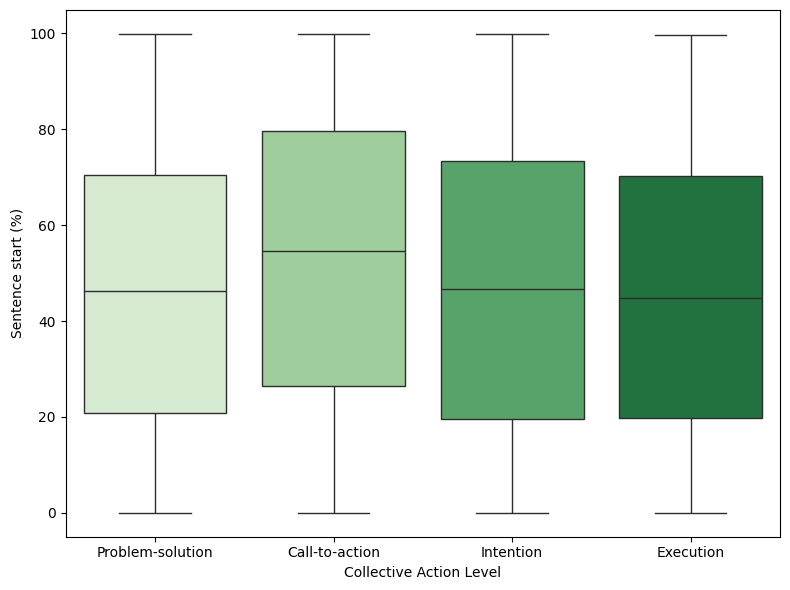

In [119]:
filtered_df = sentences_from_ca_paragraph_turns.dropna(subset=['collectiveActionMulti'])
order = [0.0, 1.0, 2.0, 3.0]
category_map = {
    0.0: 'Problem-solution',
    1.0: 'Call-to-action',
    2.0: 'Intention',
    3.0: 'Execution'
}
filtered_df['category'] = filtered_df['collectiveActionMulti'].map(category_map)
plt.figure(figsize=(8, 6))
sns.boxplot(x='category', y='perc', data=filtered_df, order=['Problem-solution', 'Call-to-action', 'Intention', 'Execution'], palette='Greens')
plt.xlabel('Collective Action Level')
plt.ylabel('Sentence start (%)')
plt.tight_layout()
plt.show()